In [6]:
# Data Science Job Market & Salary Analytics

# Objective
"""
Analyze data science job postings to understand:
- Job demand
- Salary patterns
- Experience requirements
- Location trends
- In-demand technical skills
"""

'\nAnalyze data science job postings to understand:\n- Job demand\n- Salary patterns\n- Experience requirements\n- Location trends\n- In-demand technical skills\n'

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("DataScience_salaries_2025.csv")

In [9]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,MI,FT,Research Scientist,208000,USD,208000,US,0,US,M
1,2025,MI,FT,Research Scientist,147000,USD,147000,US,0,US,M
2,2025,SE,FT,Research Scientist,173000,USD,173000,US,0,US,M
3,2025,SE,FT,Research Scientist,117000,USD,117000,US,0,US,M
4,2025,MI,FT,AI Engineer,100000,USD,100000,US,100,US,M


In [10]:
df.shape

(46637, 11)

In [11]:
df.info

<bound method DataFrame.info of        work_year experience_level employment_type                 job_title  \
0           2025               MI              FT        Research Scientist   
1           2025               MI              FT        Research Scientist   
2           2025               SE              FT        Research Scientist   
3           2025               SE              FT        Research Scientist   
4           2025               MI              FT               AI Engineer   
...          ...              ...             ...                       ...   
46632       2020               SE              FT            Data Scientist   
46633       2021               MI              FT  Principal Data Scientist   
46634       2020               EN              FT            Data Scientist   
46635       2020               EN              CT     Business Data Analyst   
46636       2021               SE              FT            Data Scientist   

        salary sala

In [12]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
work_year,46637.0,NaN,NaN,NaN,2024.113837,0.725142,2020.0,2024.0,2024.0,2025.0,2025.0
experience_level,46637,4,SE,24749,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,46637,4,FT,46185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,46637,317,Data Scientist,5392,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,46637.0,NaN,NaN,NaN,160979.641486,305258.340084,14000.0,96475.0,140000.0,192000.0,30400000.0
salary_currency,46637,26,USD,43016,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_in_usd,46637.0,NaN,NaN,NaN,151411.819993,77492.347696,15000.0,96400.0,139100.0,190500.0,800000.0
employee_residence,46637,96,US,39455,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_ratio,46637.0,NaN,NaN,NaN,24.960868,43.095411,0.0,0.0,0.0,50.0,100.0
company_location,46637,90,US,39512,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.duplicated().sum

<bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
46632    False
46633    False
46634    False
46635    False
46636    False
Length: 46637, dtype: bool>

In [14]:
df=df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [17]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [18]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [19]:
df.nunique().sort_values()

company_size             3
remote_ratio             3
experience_level         4
employment_type          4
work_year                6
salary_currency         26
company_location        90
employee_residence      96
job_title              317
salary                8673
salary_in_usd         9535
dtype: int64

In [20]:
df["job_title"].value_counts().head(20)

job_title
Data Scientist                   5392
Data Engineer                    5134
Data Analyst                     4570
Software Engineer                3172
Engineer                         2712
Machine Learning Engineer        2688
Manager                          2171
Analyst                          1439
Research Scientist               1074
Analytics Engineer                947
Data Architect                    896
Product Manager                   805
Associate                         758
Research Engineer                 666
AI Engineer                       602
Data Manager                      502
Consultant                        440
Applied Scientist                 434
Business Intelligence Analyst     431
Data Specialist                   420
Name: count, dtype: int64

In [21]:
df["work_year"].value_counts()

work_year
2024    27686
2025    13013
2023     4536
2022     1113
2021      214
2020       75
Name: count, dtype: int64

In [22]:
df["experience_level"].value_counts()

experience_level
SE    24749
MI    15049
EN     5391
EX     1448
Name: count, dtype: int64

In [23]:
df["salary"].describe()

count    4.663700e+04
mean     1.609796e+05
std      3.052583e+05
min      1.400000e+04
25%      9.647500e+04
50%      1.400000e+05
75%      1.920000e+05
max      3.040000e+07
Name: salary, dtype: float64

In [24]:
df["salary"].isnull().sum()

np.int64(0)

In [25]:
df.dtypes

work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

In [26]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicates:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())

Rows: 46637
Columns: 11
Duplicates: 0
Missing values: 0


In [27]:
print("Minimum salary:", df["salary_in_usd"].min())
print("Maximum salary:", df["salary_in_usd"].max())
print("Average salary:", df["salary_in_usd"].mean())
print("Median salary:", df["salary_in_usd"].median())

Minimum salary: 15000
Maximum salary: 800000
Average salary: 151411.81999270964
Median salary: 139100.0


In [28]:
df["remote_ratio"].value_counts().sort_index()

remote_ratio
0      34848
50       296
100    11493
Name: count, dtype: int64

In [29]:
df["company_size"].value_counts()

company_size
M    45117
L     1310
S      210
Name: count, dtype: int64

In [30]:
yearly_jobs=df["work_year"].value_counts().sort_index()

In [31]:
print("Remote ratio:")
print(df["remote_ratio"].value_counts().sort_index())

print("\nCompany size:")
print(df["company_size"].value_counts())

Remote ratio:
remote_ratio
0      34848
50       296
100    11493
Name: count, dtype: int64

Company size:
company_size
M    45117
L     1310
S      210
Name: count, dtype: int64


In [32]:
df["employment_type"].value_counts()

employment_type
FT    46185
CT      220
PT      216
FL       16
Name: count, dtype: int64

In [33]:
df["salary_in_usd"].describe()

count     46637.000000
mean     151411.819993
std       77492.347696
min       15000.000000
25%       96400.000000
50%      139100.000000
75%      190500.000000
max      800000.000000
Name: salary_in_usd, dtype: float64

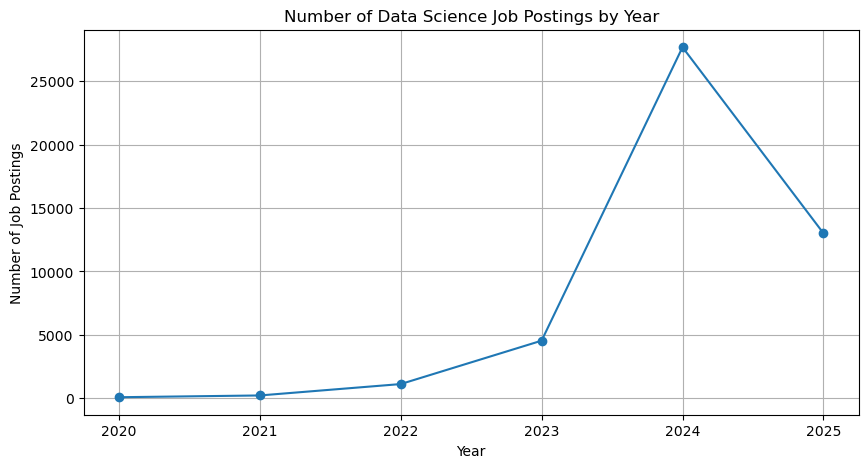

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_jobs.index,
    yearly_jobs.values,
    marker="o"
)

plt.title("Number of Data Science Job Postings by Year")
plt.xlabel("Year")
plt.ylabel("Number of Job Postings")
plt.grid(True)

plt.show()

In [35]:
## top 10 job roles 

In [36]:
top_jobs=df["job_title"].value_counts().head(10)
top_jobs

job_title
Data Scientist               5392
Data Engineer                5134
Data Analyst                 4570
Software Engineer            3172
Engineer                     2712
Machine Learning Engineer    2688
Manager                      2171
Analyst                      1439
Research Scientist           1074
Analytics Engineer            947
Name: count, dtype: int64

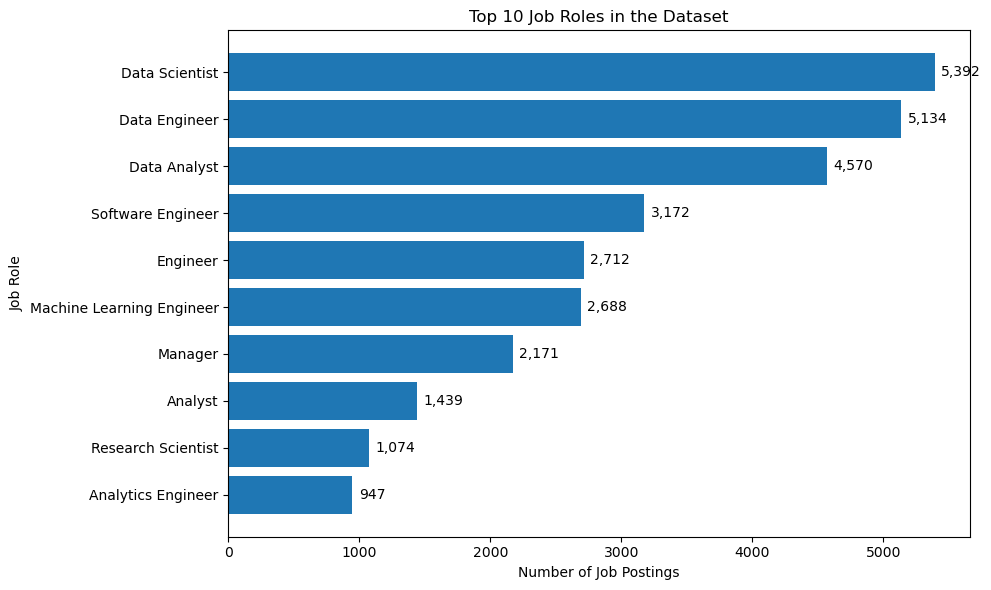

In [37]:
plt.figure(figsize=(10, 6))

bars = plt.barh(top_jobs.index[::-1], top_jobs.values[::-1])

plt.title("Top 10 Job Roles in the Dataset")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Role")

# Add number of postings to each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 50,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [38]:
## salary by experience level 

In [39]:
salary_experience = df.groupby("experience_level")["salary_in_usd"].mean().sort_values()

salary_experience

experience_level
EN     97693.093489
MI    137819.483421
SE    168514.610853
EX    200356.403315
Name: salary_in_usd, dtype: float64

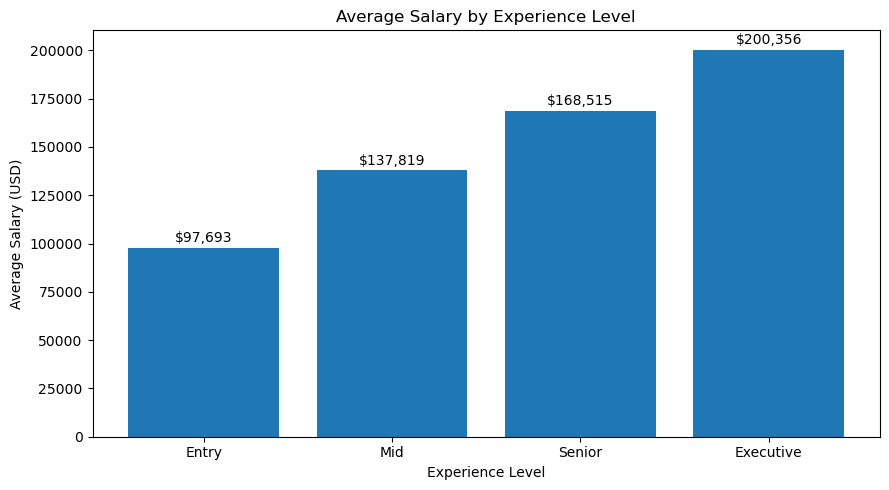

In [40]:
salary_experience = (
    df.groupby("experience_level")["salary_in_usd"]
    .mean()
    .reindex(["EN", "MI", "SE", "EX"])
)

labels = ["Entry", "Mid", "Senior", "Executive"]

plt.figure(figsize=(9, 5))

bars = plt.bar(labels, salary_experience.values)

plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 3000,
        f"${value:,.0f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [41]:
remote_labels = {
    0: "On-site",
    50: "Hybrid",
    100: "Fully Remote"
}

remote_jobs = df["remote_ratio"].map(remote_labels).value_counts()

remote_jobs

remote_ratio
On-site         34848
Fully Remote    11493
Hybrid            296
Name: count, dtype: int64

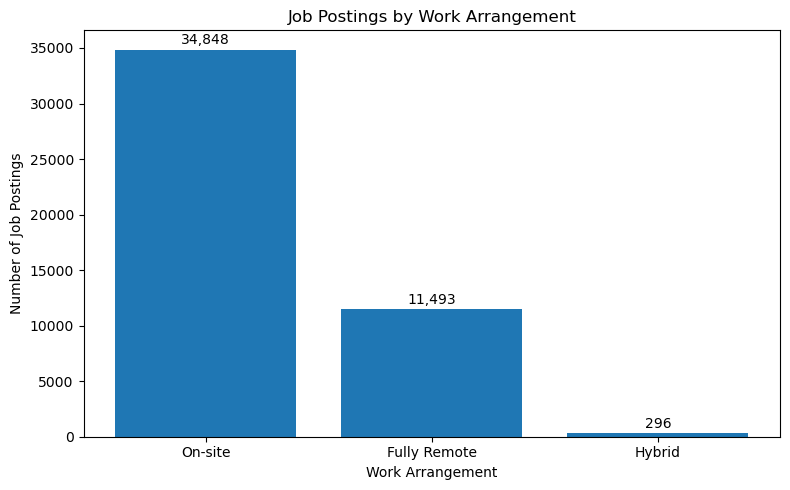

In [42]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    remote_jobs.index,
    remote_jobs.values
)

plt.title("Job Postings by Work Arrangement")
plt.xlabel("Work Arrangement")
plt.ylabel("Number of Job Postings")

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 500,
        f"{int(value):,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [43]:
remote_percentage = (remote_jobs / len(df) * 100).round(2)

remote_percentage

remote_ratio
On-site         74.72
Fully Remote    24.64
Hybrid           0.63
Name: count, dtype: float64

In [44]:
salary_by_role = (
    df.groupby("job_title")["salary_in_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

salary_by_role

job_title
Analytics Engineering Manager            399880.000000
Data Science Tech Lead                   375000.000000
Applied AI ML Lead                       292500.000000
Head of Machine Learning                 283573.545455
Director of Machine Learning             273947.222222
Machine Learning Performance Engineer    262500.000000
AWS Data Architect                       258000.000000
Engineering Manager                      251996.190476
Cloud Data Architect                     250000.000000
Enterprise Account Executive             244900.619048
Name: salary_in_usd, dtype: float64

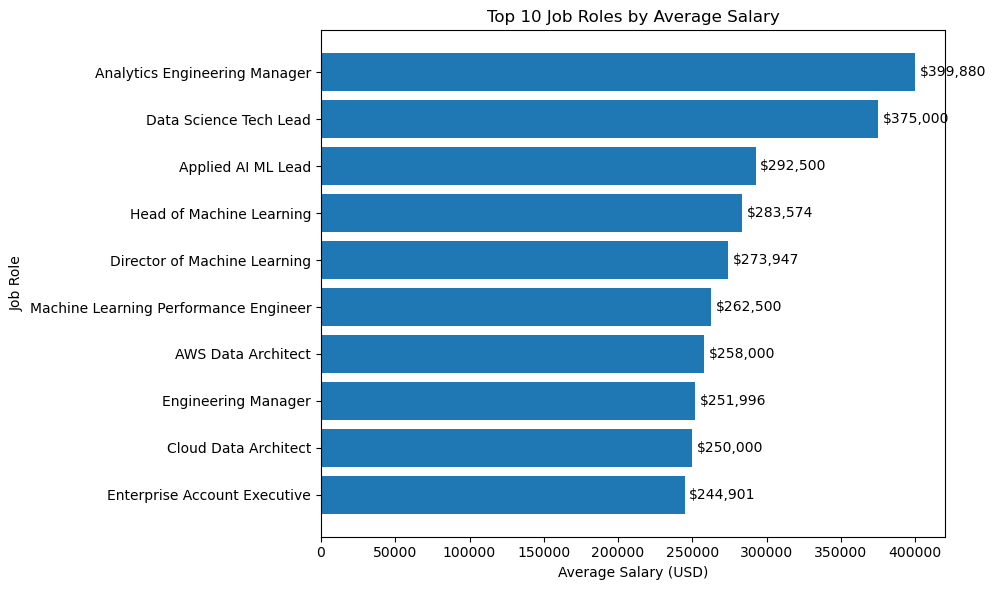

In [45]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    salary_by_role.index[::-1],
    salary_by_role.values[::-1]
)

plt.title("Top 10 Job Roles by Average Salary")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Job Role")

for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 3000,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [46]:
df.groupby("job_title").agg(
    job_count=("job_title", "count"),
    average_salary=("salary_in_usd", "mean")
).sort_values("average_salary", ascending=False).head(10)

,job_count,average_salary
job_title,,
Analytics Engineering Manager,1,399880.000000
Data Science Tech Lead,1,375000.000000
Applied AI ML Lead,2,292500.000000
Head of Machine Learning,11,283573.545455
Director of Machine Learning,18,273947.222222
Machine Learning Performance Engineer,2,262500.000000
AWS Data Architect,1,258000.000000
Engineering Manager,315,251996.190476
Cloud Data Architect,1,250000.000000


In [47]:
role_salary = (
    df.groupby("job_title")
    .agg(
        job_count=("job_title", "count"),
        average_salary=("salary_in_usd", "mean")
    )
)

reliable_roles = (
    role_salary[role_salary["job_count"] >= 50]
    .sort_values("average_salary", ascending=False)
    .head(10)
)

reliable_roles

,job_count,average_salary
job_title,,
Engineering Manager,315,251996.190476
Head of Data,166,220591.674699
AI Architect,125,217205.304000
Research Engineer,666,196898.345345
Research Scientist,1074,194780.116387
Architect,210,191702.104762
Applied Scientist,434,191614.490783
Member of Technical Staff,51,189945.098039
Product Manager,805,188948.906832


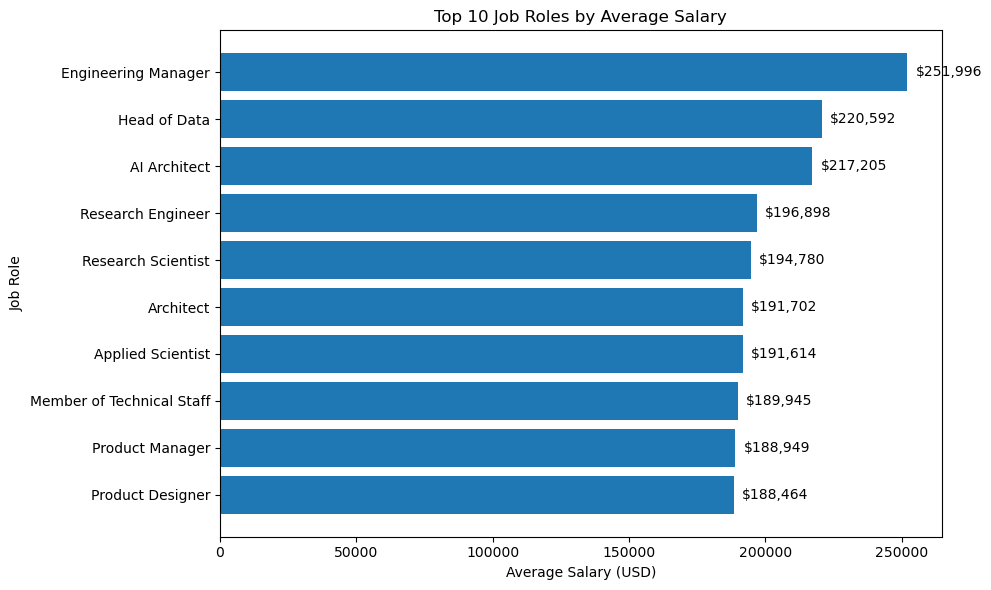

In [48]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    reliable_roles.index[::-1],
    reliable_roles["average_salary"].values[::-1]
)

plt.title("Top 10 Job Roles by Average Salary")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Job Role")

for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 3000,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [49]:
company_size_labels = {
    "S": "Small",
    "M": "Medium",
    "L": "Large"
}

company_jobs = (
    df["company_size"]
    .map(company_size_labels)
    .value_counts()
)

company_jobs

company_size
Medium    45117
Large      1310
Small       210
Name: count, dtype: int64

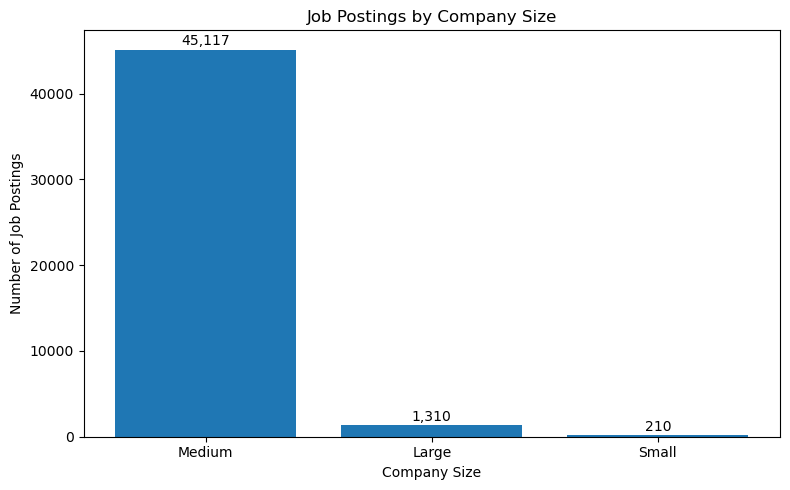

In [50]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    company_jobs.index,
    company_jobs.values
)

plt.title("Job Postings by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Number of Job Postings")

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 500,
        f"{int(value):,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [51]:
top_locations = df["company_location"].value_counts().head(10)

top_locations

company_location
US    39512
CA     2634
GB     1875
AU      283
DE      245
FR      186
LT      181
NL      174
ES      140
IN      121
Name: count, dtype: int64

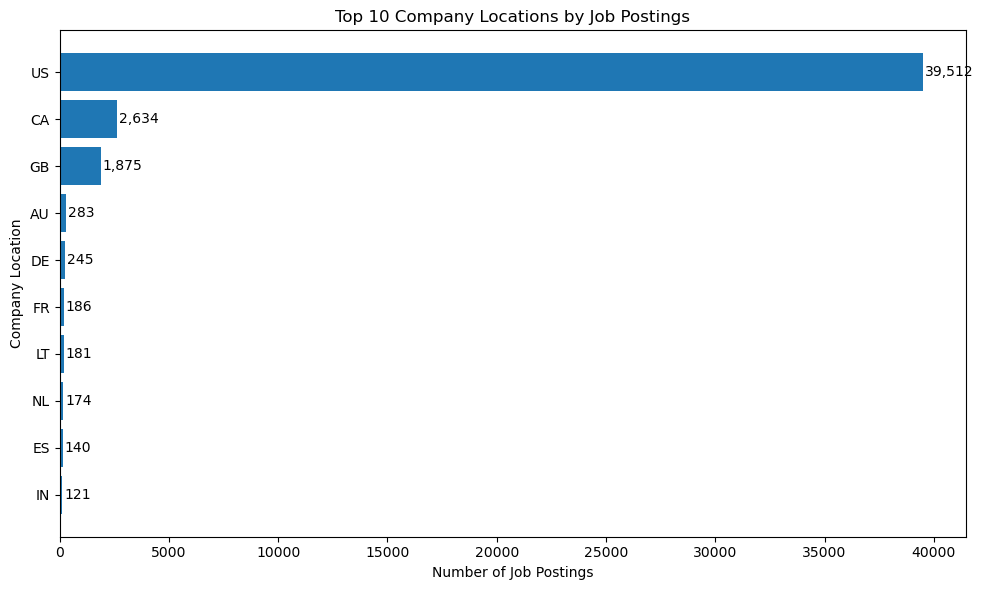

In [52]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_locations.index[::-1],
    top_locations.values[::-1]
)

plt.title("Top 10 Company Locations by Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company Location")

for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 100,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value):,}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [53]:
location_percentage = (top_locations / len(df) * 100).round(2)

location_percentage

company_location
US    84.72
CA     5.65
GB     4.02
AU     0.61
DE     0.53
FR     0.40
LT     0.39
NL     0.37
ES     0.30
IN     0.26
Name: count, dtype: float64

In [54]:
location_salary = (
    df.groupby("company_location")
    .agg(
        job_count=("company_location", "count"),
        average_salary=("salary_in_usd", "mean")
    )
)

reliable_locations = (
    location_salary[location_salary["job_count"] >= 100]
    .sort_values("average_salary", ascending=False)
    .head(10)
)

reliable_locations

,job_count,average_salary
company_location,,
US,39512,159799.839163
CA,2634,131132.484055
AU,283,127338.501767
DE,245,101174.318367
GB,1875,98999.108800
FR,186,79880.548387
NL,174,79440.137931
ES,140,71010.314286
AT,102,67685.323529


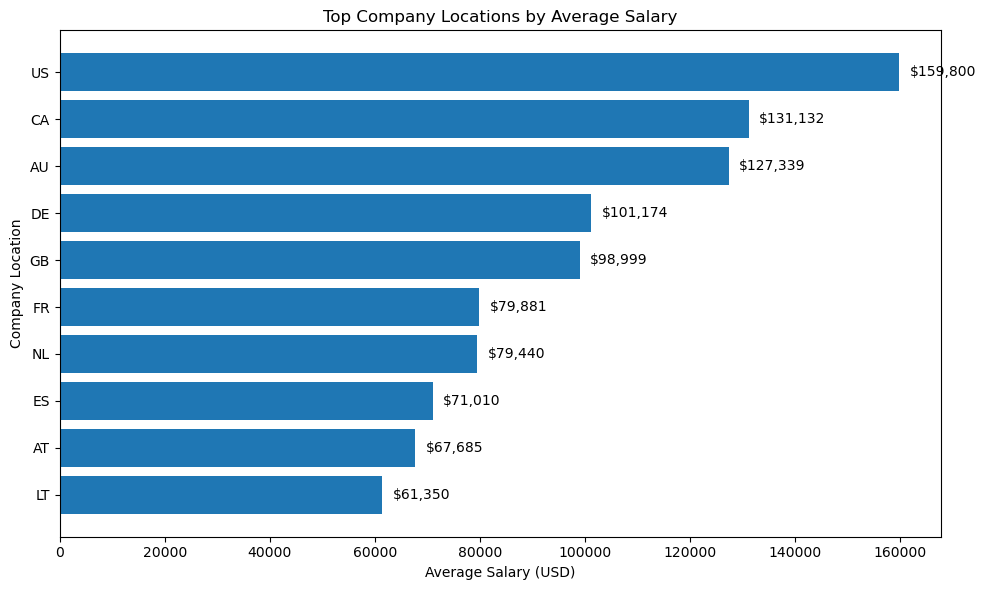

In [55]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    reliable_locations.index[::-1],
    reliable_locations["average_salary"].values[::-1]
)

plt.title("Top Company Locations by Average Salary")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Company Location")

for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 2000,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [56]:
## feature Engineering 

In [57]:
experience_mapping = {
    "EN": "Entry",
    "MI": "Mid",
    "SE": "Senior",
    "EX": "Executive"
}

df["experience_level_name"] =df["experience_level"].map(experience_mapping)

In [58]:
df[["experience_level", "experience_level_name"]].drop_duplicates()

,experience_level,experience_level_name
0,MI,Mid
2,SE,Senior
10,EN,Entry
42,EX,Executive


In [59]:
remote_mapping = {
    0: "On-site",
    50: "Hybrid",
    100: "Fully Remote"
}

df["work_arrangement"] = df["remote_ratio"].map(remote_mapping)

In [60]:
df[["remote_ratio", "work_arrangement"]].drop_duplicates()

,remote_ratio,work_arrangement
0,0,On-site
4,100,Fully Remote
1318,50,Hybrid


In [61]:
company_size_mapping = {
    "S": "Small",
    "M": "Medium",
    "L": "Large"
}

df["company_size_name"] = df["company_size"].map(company_size_mapping)

In [62]:
df[["company_size", "company_size_name"]].drop_duplicates()

,company_size,company_size_name
0,M,Medium
424,L,Large
3713,S,Small


In [63]:
def salary_category(salary):
    if salary < 100000:
        return "Below $100K"
    elif salary < 200000:
        return "$100K-$200K"
    else:
        return "Above $200K"

df["salary_category"] = df["salary_in_usd"].apply(salary_category)

In [64]:
df["salary_category"].value_counts()

salary_category
$100K-$200K    23728
Below $100K    12511
Above $200K    10398
Name: count, dtype: int64

In [66]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_name,work_arrangement,company_size_name,salary_category
0,2025,MI,FT,Research Scientist,208000,USD,208000,US,0,US,M,Mid,On-site,Medium,Above $200K
1,2025,MI,FT,Research Scientist,147000,USD,147000,US,0,US,M,Mid,On-site,Medium,$100K-$200K
2,2025,SE,FT,Research Scientist,173000,USD,173000,US,0,US,M,Senior,On-site,Medium,$100K-$200K
3,2025,SE,FT,Research Scientist,117000,USD,117000,US,0,US,M,Senior,On-site,Medium,$100K-$200K
4,2025,MI,FT,AI Engineer,100000,USD,100000,US,100,US,M,Mid,Fully Remote,Medium,$100K-$200K


In [67]:
df.shape

(46637, 15)

In [69]:
df.to_csv(
    "final_dataset.csv",
    index=False
)

In [70]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Rows: 46637
Columns: 15
Missing values: 0
Duplicates: 0
